# Motor Imagery EEG Decoding

In [1]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mne.datasets import eegbci
from mne.decoding import CSP

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
print("Environment ready!")

Environment ready!


## 1. Project Motivation
This project explores whether left- and right-hand motor imagery can be decoded from EEG signals using statistical and machine learning methods.

## 2. Dataset
EEG data were obtained from the PhysioNet EEG Motor Movement/Imagery Dataset. Subject 1 was analyzed using Runs 4, 8, and 12, which contain left- versus right-hand motor imagery tasks. The recordings contain 64 EEG channels sampled at 160 Hz.

In [2]:
subject = 1
runs = [4, 8, 12]

raw_files = eegbci.load_data(
    subjects=subject,
    runs=runs,
    update_path=False
)

raw = mne.io.read_raw_edf(
    raw_files[0],
    preload=True
)

eegbci.standardize(raw)
raw.set_montage("colin27_1005")

Using default location ~/mne_data for EEGBCI...
Extracting EDF parameters from C:\Users\13706\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

## 3. EEG Preprocessing
The EEG recordings were loaded using MNE-Python and standardized to a common electrode montage. Motor-imagery-related frequency ranges were later isolated using band-pass filtering.

In [3]:
%matplotlib qt

Using matplotlib as 2D backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


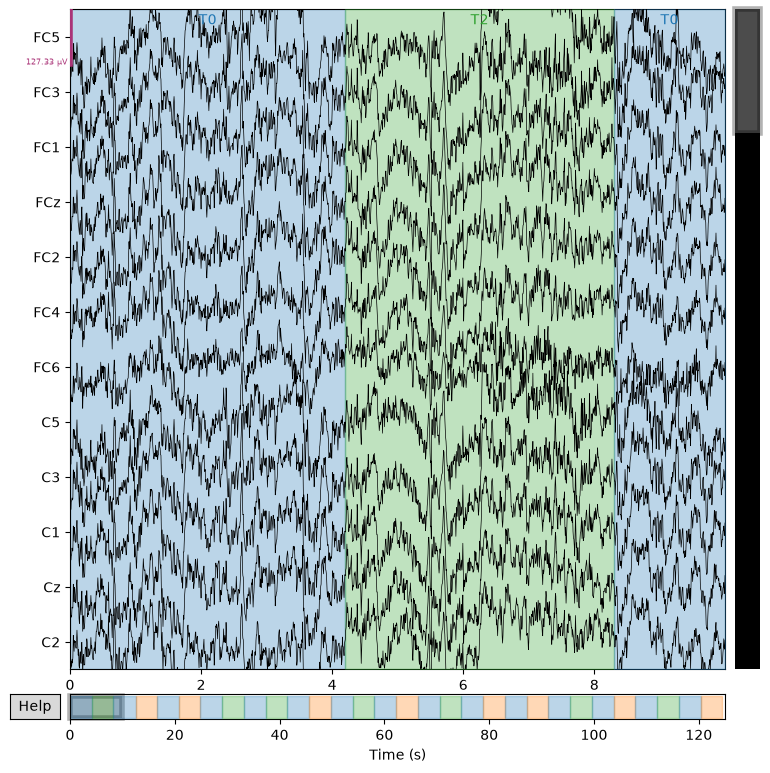

In [4]:
raw.plot(
    duration=10,
    n_channels=12,
    scalings="auto"
)

In [5]:
events, event_id = mne.events_from_annotations(raw)

print(event_id)
print(events[:10])

Used Annotations descriptions: ['T0', 'T1', 'T2']
{'T0': 1, 'T1': 2, 'T2': 3}
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    3]]


In [6]:
event_id_motor = {
    "left": 2,
    "right": 3
}

print(event_id_motor)

{'left': 2, 'right': 3}


## 4. Epoch Construction
Continuous EEG was segmented into 4-second epochs based on experimental event markers. T1 corresponded to left-hand motor imagery and T2 to right-hand motor imagery.

In [7]:
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id_motor,
    tmin=0,
    tmax=4,
    baseline=None,
    preload=True
)

print(epochs)

Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 15 events and 641 original time points ...
0 bad epochs dropped
<Epochs | 15 events (all good), 0 – 4 s (baseline off), ~4.8 MiB, data loaded,
 'left': 8
 'right': 7>


In [8]:
X = epochs.get_data()

print("EEG data shape:", X.shape)

print("Number of trials:", len(epochs))

print("Left trials:", len(epochs["left"]))

print("Right trials:", len(epochs["right"]))

EEG data shape: (15, 64, 641)
Number of trials: 15
Left trials: 8
Right trials: 7


In [9]:
y = epochs.events[:, -1]

print(y)

[3 2 2 3 3 2 3 2 3 2 2 3 2 3 2]


In [10]:
epochs_filtered = epochs.copy().filter(
    l_freq=8,
    h_freq=30
)

Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



In [11]:
epochs_central = epochs_filtered.copy().pick(["C3", "C4"])

print(epochs_central)

<Epochs | 15 events (all good), 0 – 4 s (baseline off), ~181 KiB, data loaded,
 'left': 8
 'right': 7>


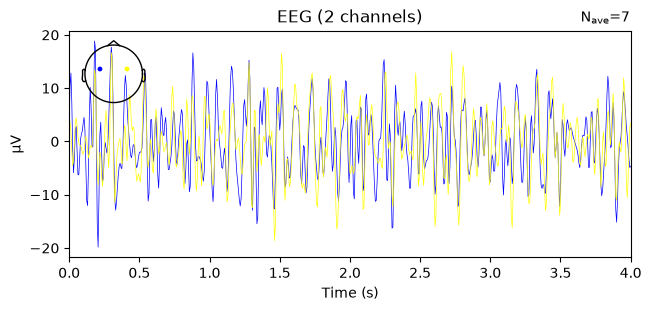

In [12]:
left_evoked = epochs_central["left"].average()
right_evoked = epochs_central["right"].average()

left_evoked.plot()
right_evoked.plot()

In [13]:
psd_left = epochs_central["left"].compute_psd(
    fmin=8,
    fmax=30
)

psd_right = epochs_central["right"].compute_psd(
    fmin=8,
    fmax=30
)

    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows


Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


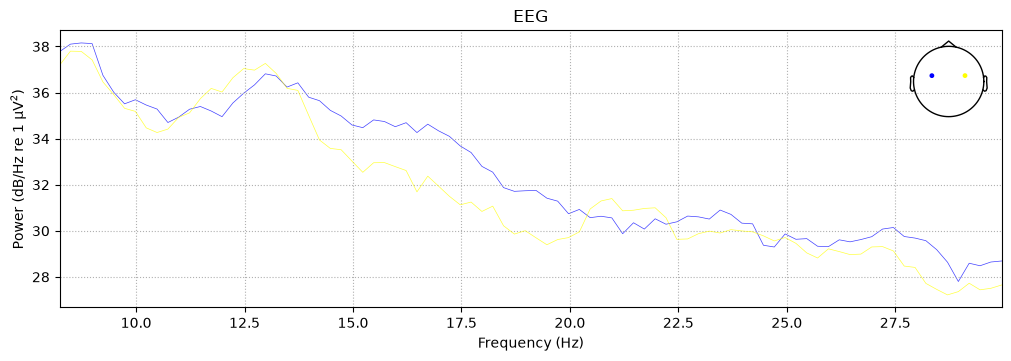

In [14]:
psd_left.plot()
psd_right.plot()

## 5. Band-Power Feature Extraction
Mu-band (8–13 Hz) and beta-band (13–30 Hz) power were extracted from electrodes C3 and C4. These four band-power measures were used as manually engineered features for the baseline classifier.

In [15]:
epochs_features = epochs.copy().pick(["C3", "C4"])

psd = epochs_features.compute_psd(
    method="welch",
    fmin=8,
    fmax=30
)

psd_data = psd.get_data()
freqs = psd.freqs

print("PSD shape:", psd_data.shape)
print("Frequencies:", freqs[:10])

Effective window size : 4.006 (s)
PSD shape: (15, 2, 88)
Frequencies: [ 8.23712949  8.48673947  8.73634945  8.98595944  9.23556942  9.48517941
  9.73478939  9.98439938 10.23400936 10.48361934]


In [16]:
mu_mask = (freqs >= 8) & (freqs < 13)
beta_mask = (freqs >= 13) & (freqs <= 30)

print(freqs[mu_mask])
print(freqs[beta_mask])

[ 8.23712949  8.48673947  8.73634945  8.98595944  9.23556942  9.48517941
  9.73478939  9.98439938 10.23400936 10.48361934 10.73322933 10.98283931
 11.2324493  11.48205928 11.73166927 11.98127925 12.23088924 12.48049922
 12.7301092  12.97971919]
[13.22932917 13.47893916 13.72854914 13.97815913 14.22776911 14.4773791
 14.72698908 14.97659906 15.22620905 15.47581903 15.72542902 15.975039
 16.22464899 16.47425897 16.72386895 16.97347894 17.22308892 17.47269891
 17.72230889 17.97191888 18.22152886 18.47113885 18.72074883 18.97035881
 19.2199688  19.46957878 19.71918877 19.96879875 20.21840874 20.46801872
 20.71762871 20.96723869 21.21684867 21.46645866 21.71606864 21.96567863
 22.21528861 22.4648986  22.71450858 22.96411856 23.21372855 23.46333853
 23.71294852 23.9625585  24.21216849 24.46177847 24.71138846 24.96099844
 25.21060842 25.46021841 25.70982839 25.95943838 26.20904836 26.45865835
 26.70826833 26.95787832 27.2074883  27.45709828 27.70670827 27.95631825
 28.20592824 28.45553822 28.

In [17]:
c3_mu = psd_data[:, 0, :][:, mu_mask].mean(axis=1)
c4_mu = psd_data[:, 1, :][:, mu_mask].mean(axis=1)

c3_beta = psd_data[:, 0, :][:, beta_mask].mean(axis=1)
c4_beta = psd_data[:, 1, :][:, beta_mask].mean(axis=1)

print("C3 mu:", c3_mu)
print("C4 mu:", c4_mu)

C3 mu: [3.43766157e-11 1.97120695e-11 3.98726825e-11 1.98792339e-11
 1.31873324e-11 3.02363786e-11 3.01263714e-11 3.11236275e-11
 3.11255792e-11 3.94033440e-11 1.70964570e-11 3.15687983e-11
 2.67687336e-11 2.18946400e-11 5.07364369e-11]
C4 mu: [2.94001136e-11 1.85559095e-11 1.64090928e-11 1.74111068e-11
 1.12464910e-11 1.31661332e-11 4.46798059e-11 3.01900060e-11
 2.15819457e-11 2.60634595e-11 1.44974275e-11 2.56688693e-11
 1.46138325e-11 4.61097324e-11 2.79094252e-11]


In [18]:
features = pd.DataFrame({
    "C3_mu": c3_mu,
    "C4_mu": c4_mu,
    "C3_beta": c3_beta,
    "C4_beta": c4_beta,
    "label": y
})

features["hand"] = features["label"].map({
    2: "Left",
    3: "Right"
})

features

,C3_mu,C4_mu,C3_beta,C4_beta,label,hand
0,3.437662e-11,2.940011e-11,9.793779e-12,7.578684e-12,3,Right
1,1.971207e-11,1.855591e-11,8.983360e-12,5.923973e-12,2,Left
2,3.987268e-11,1.640909e-11,8.190700e-12,6.807158e-12,2,Left
3,1.987923e-11,1.741111e-11,7.051556e-12,6.233240e-12,3,Right
4,1.318733e-11,1.124649e-11,8.381485e-12,6.831145e-12,3,Right
5,3.023638e-11,1.316613e-11,1.050578e-11,9.329837e-12,2,Left
6,3.012637e-11,4.467981e-11,1.222557e-11,9.187830e-12,3,Right
7,3.112363e-11,3.019001e-11,1.052753e-11,7.150201e-12,2,Left
8,3.112558e-11,2.158195e-11,9.523591e-12,7.344435e-12,3,Right
9,3.940334e-11,2.606346e-11,1.366388e-11,7.796088e-12,2,Left


## 6. Logistic Regression Baseline
Logistic regression was used as a baseline classifier. Performance was first evaluated with 5-fold cross-validation and later with a held-out recording run.

In [19]:
for label, hand in [(2, "Left"), (3, "Right")]:
    subset = features[features["label"] == label]

    plt.scatter(
        subset["C3_mu"],
        subset["C4_mu"],
        label=hand
    )

plt.xlabel("C3 mu power")
plt.ylabel("C4 mu power")
plt.legend()
plt.show()

In [20]:
X_model = features[["C3_mu", "C4_mu"]]
y_model = features["label"]

model = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

scores = cross_val_score(
    model,
    X_model,
    y_model,
    cv=5
)

print("CV scores:", scores)
print("Mean accuracy:", scores.mean())

CV scores: [0.         0.66666667 0.33333333 0.33333333 1.        ]
Mean accuracy: 0.4666666666666666


In [21]:
X_model_4 = features[
    ["C3_mu", "C4_mu", "C3_beta", "C4_beta"]
]

y_model = features["label"]

model_4 = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

scores_4 = cross_val_score(
    model_4,
    X_model_4,
    y_model,
    cv=5
)

print("4-feature CV scores:", scores_4)
print("4-feature mean accuracy:", scores_4.mean())

4-feature CV scores: [0.33333333 0.33333333 0.33333333 1.         1.        ]
4-feature mean accuracy: 0.6


In [22]:
raw8 = mne.io.read_raw_edf(
    raw_files[1],
    preload=True
)

eegbci.standardize(raw8)
raw8.set_montage("colin27_1005")

print(raw8.info)

Extracting EDF parameters from C:\Users\13706\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<Info | 9 non-empty values
 bads: []
 ch_names: FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


In [23]:
events8, event_id8 = mne.events_from_annotations(raw8)

print(event_id8)
print(events8[:10])

Used Annotations descriptions: ['T0', 'T1', 'T2']
{'T0': 1, 'T1': 2, 'T2': 3}
[[   0    0    1]
 [ 672    0    2]
 [1328    0    1]
 [2000    0    3]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    2]]


In [24]:
epochs8 = mne.Epochs(
    raw8,
    events8,
    event_id={
        "left": 2,
        "right": 3
    },
    tmin=0,
    tmax=4,
    baseline=None,
    preload=True
)

print(epochs8)

Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 15 events and 641 original time points ...
0 bad epochs dropped
<Epochs | 15 events (all good), 0 – 4 s (baseline off), ~4.8 MiB, data loaded,
 'left': 8
 'right': 7>


In [25]:
epochs_train = mne.concatenate_epochs(
    [epochs, epochs8]
)

print(epochs_train)

Not setting metadata
30 matching events found
No baseline correction applied
<EpochsArray | 30 events (all good), 0 – 4 s (baseline off), ~9.5 MiB, data loaded,
 'left': 16
 'right': 14>


C:\Users\13706\AppData\Local\Temp\ipykernel_7260\996837246.py:1: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_train = mne.concatenate_epochs(


In [26]:
epochs_features_train = epochs_train.copy().pick(["C3", "C4"])

psd_train = epochs_features_train.compute_psd(
    method="welch",
    fmin=8,
    fmax=30
)

psd_data_train = psd_train.get_data()
freqs_train = psd_train.freqs

Effective window size : 4.006 (s)


In [27]:
mu_mask_train = (freqs_train >= 8) & (freqs_train < 13)
beta_mask_train = (freqs_train >= 13) & (freqs_train <= 30)

c3_mu_train = psd_data_train[:, 0, :][:, mu_mask_train].mean(axis=1)
c4_mu_train = psd_data_train[:, 1, :][:, mu_mask_train].mean(axis=1)

c3_beta_train = psd_data_train[:, 0, :][:, beta_mask_train].mean(axis=1)
c4_beta_train = psd_data_train[:, 1, :][:, beta_mask_train].mean(axis=1)

In [28]:
y_train = epochs_train.events[:, -1]

features_train = pd.DataFrame({
    "C3_mu": c3_mu_train,
    "C4_mu": c4_mu_train,
    "C3_beta": c3_beta_train,
    "C4_beta": c4_beta_train,
    "label": y_train
})

features_train["hand"] = features_train["label"].map({
    2: "Left",
    3: "Right"
})

features_train

,C3_mu,C4_mu,C3_beta,C4_beta,label,hand
0,3.437662e-11,2.940011e-11,9.793779e-12,7.578684e-12,3,Right
1,1.971207e-11,1.855591e-11,8.983360e-12,5.923973e-12,2,Left
2,3.987268e-11,1.640909e-11,8.190700e-12,6.807158e-12,2,Left
3,1.987923e-11,1.741111e-11,7.051556e-12,6.233240e-12,3,Right
4,1.318733e-11,1.124649e-11,8.381485e-12,6.831145e-12,3,Right
5,3.023638e-11,1.316613e-11,1.050578e-11,9.329837e-12,2,Left
6,3.012637e-11,4.467981e-11,1.222557e-11,9.187830e-12,3,Right
7,3.112363e-11,3.019001e-11,1.052753e-11,7.150201e-12,2,Left
8,3.112558e-11,2.158195e-11,9.523591e-12,7.344435e-12,3,Right
9,3.940334e-11,2.606346e-11,1.366388e-11,7.796088e-12,2,Left


In [29]:
X_train_4 = features_train[
    ["C3_mu", "C4_mu", "C3_beta", "C4_beta"]
]

y_train_model = features_train["label"]

model_train = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

scores_train = cross_val_score(
    model_train,
    X_train_4,
    y_train_model,
    cv=5
)

print("Run 4 + 8 CV scores:", scores_train)
print("Mean accuracy:", scores_train.mean())

Run 4 + 8 CV scores: [0.5        0.83333333 0.66666667 0.66666667 0.83333333]
Mean accuracy: 0.7


In [30]:
raw12 = mne.io.read_raw_edf(
    raw_files[2],
    preload=True
)

eegbci.standardize(raw12)
raw12.set_montage("colin27_1005")

events12, event_id12 = mne.events_from_annotations(raw12)

print(event_id12)

Extracting EDF parameters from C:\Users\13706\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: ['T0', 'T1', 'T2']
{'T0': 1, 'T1': 2, 'T2': 3}


In [31]:
epochs12 = mne.Epochs(
    raw12,
    events12,
    event_id={
        "left": 2,
        "right": 3
    },
    tmin=0,
    tmax=4,
    baseline=None,
    preload=True
)

print(epochs12)

Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 15 events and 641 original time points ...
0 bad epochs dropped
<Epochs | 15 events (all good), 0 – 4 s (baseline off), ~4.8 MiB, data loaded,
 'left': 7
 'right': 8>


In [32]:
epochs12_features = epochs12.copy().pick(["C3", "C4"])

psd12 = epochs12_features.compute_psd(
    method="welch",
    fmin=8,
    fmax=30
)

psd_data12 = psd12.get_data()
freqs12 = psd12.freqs

mu_mask12 = (freqs12 >= 8) & (freqs12 < 13)
beta_mask12 = (freqs12 >= 13) & (freqs12 <= 30)

c3_mu12 = psd_data12[:, 0, :][:, mu_mask12].mean(axis=1)
c4_mu12 = psd_data12[:, 1, :][:, mu_mask12].mean(axis=1)

c3_beta12 = psd_data12[:, 0, :][:, beta_mask12].mean(axis=1)
c4_beta12 = psd_data12[:, 1, :][:, beta_mask12].mean(axis=1)

Effective window size : 4.006 (s)


In [33]:
y12 = epochs12.events[:, -1]

features12 = pd.DataFrame({
    "C3_mu": c3_mu12,
    "C4_mu": c4_mu12,
    "C3_beta": c3_beta12,
    "C4_beta": c4_beta12,
    "label": y12
})

features12

,C3_mu,C4_mu,C3_beta,C4_beta,label
0,1.017710e-11,1.281978e-11,7.384639e-12,6.914675e-12,3
1,2.304006e-11,2.091523e-11,7.695561e-12,8.711497e-12,2
2,1.603743e-11,1.688839e-11,6.251112e-12,4.829148e-12,3
3,1.802335e-11,1.584554e-11,7.317559e-12,4.962892e-12,2
4,8.339335e-11,3.183785e-11,1.343581e-11,9.529040e-12,2
5,5.729810e-11,4.669605e-11,9.099914e-12,7.838936e-12,3
6,3.464954e-11,2.314522e-11,9.618417e-12,7.074586e-12,3
7,3.014744e-11,2.416356e-11,1.115512e-11,7.887005e-12,2
8,1.225499e-10,2.566159e-11,7.607831e-12,6.288740e-12,2
9,4.007435e-11,4.516884e-11,9.647295e-12,8.362011e-12,3


## 7. Cross-Session Evaluation“
Runs 4 and 8 were used for training, while Run 12 was held out for cross-run evaluation. This setup evaluates how well the decoder generalizes across recording runs.

In [34]:
X_train = features_train[
    ["C3_mu", "C4_mu", "C3_beta", "C4_beta"]
]

y_train = features_train["label"]

X_test = features12[
    ["C3_mu", "C4_mu", "C3_beta", "C4_beta"]
]

y_test = features12["label"]

model_final = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

model_final.fit(X_train, y_train)

test_accuracy = model_final.score(X_test, y_test)

print("Run 12 test accuracy:", test_accuracy)

Run 12 test accuracy: 0.6


In [35]:
y_pred = model_final.predict(X_test)

print("True labels:     ", y_test.to_numpy())
print("Predicted labels:", y_pred)

True labels:      [3 2 3 2 2 3 3 2 2 3 3 2 3 2 3]
Predicted labels: [2 3 3 2 3 3 3 2 3 3 3 2 3 3 2]


In [36]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[2, 3]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Left", "Right"]
)

disp.plot()
plt.title("Run 12 Confusion Matrix")
plt.show()

In [37]:
results12 = features12.copy()

results12["predicted_label"] = y_pred

results12["true_hand"] = results12["label"].map({
    2: "Left",
    3: "Right"
})

results12["predicted_hand"] = results12["predicted_label"].map({
    2: "Left",
    3: "Right"
})

results12["correct"] = (
    results12["label"] == results12["predicted_label"]
)

results12[
    ["C3_mu", "C4_mu", "C3_beta", "C4_beta",
     "true_hand", "predicted_hand", "correct"]
]

,C3_mu,C4_mu,C3_beta,C4_beta,true_hand,predicted_hand,correct
0,1.017710e-11,1.281978e-11,7.384639e-12,6.914675e-12,Right,Left,False
1,2.304006e-11,2.091523e-11,7.695561e-12,8.711497e-12,Left,Right,False
2,1.603743e-11,1.688839e-11,6.251112e-12,4.829148e-12,Right,Right,True
3,1.802335e-11,1.584554e-11,7.317559e-12,4.962892e-12,Left,Left,True
4,8.339335e-11,3.183785e-11,1.343581e-11,9.529040e-12,Left,Right,False
5,5.729810e-11,4.669605e-11,9.099914e-12,7.838936e-12,Right,Right,True
6,3.464954e-11,2.314522e-11,9.618417e-12,7.074586e-12,Right,Right,True
7,3.014744e-11,2.416356e-11,1.115512e-11,7.887005e-12,Left,Left,True
8,1.225499e-10,2.566159e-11,7.607831e-12,6.288740e-12,Left,Right,False
9,4.007435e-11,4.516884e-11,9.647295e-12,8.362011e-12,Right,Right,True


## 8. CSP + LDA
Common Spatial Patterns (CSP) were used to learn discriminative spatial combinations across all 64 EEG channels. The resulting CSP features were classified using Linear Discriminant Analysis (LDA).

In [38]:
epochs_train_csp = epochs_train.copy().filter(
    l_freq=8,
    h_freq=30
)

epochs12_csp = epochs12.copy().filter(
    l_freq=8,
    h_freq=30
)

X_csp_train = epochs_train_csp.get_data()
y_csp_train = epochs_train_csp.events[:, -1]

X_csp_test = epochs12_csp.get_data()
y_csp_test = epochs12_csp.events[:, -1]

print("Training shape:", X_csp_train.shape)
print("Test shape:", X_csp_test.shape)

Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)

Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filt

In [39]:
csp = CSP(
    n_components=4,
    reg=None,
    log=True,
    norm_trace=False
)

lda = LinearDiscriminantAnalysis()

csp_lda = make_pipeline(
    csp,
    lda
)

In [40]:
csp_scores = cross_val_score(
    csp_lda,
    X_csp_train,
    y_csp_train,
    cv=5
)

print("CSP + LDA CV scores:", csp_scores)
print("CSP + LDA mean CV accuracy:", csp_scores.mean())

Computing rank from data with rank=None
    Using tolerance 0.00022 (2.2e-16 eps * 64 dim * 1.5e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00021 (2.2e-16 eps * 64 dim * 1.5e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00022 (2.2e-16 eps * 64 dim * 1.5e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMP

In [41]:
csp_lda.fit(
    X_csp_train,
    y_csp_train
)

csp_test_accuracy = csp_lda.score(
    X_csp_test,
    y_csp_test
)

print("CSP + LDA Run 12 accuracy:", csp_test_accuracy)

Computing rank from data with rank=None
    Using tolerance 0.00024 (2.2e-16 eps * 64 dim * 1.7e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
CSP + LDA Run 12 accuracy: 0.6666666666666666


In [42]:
y_pred_csp = csp_lda.predict(X_csp_test)

print("True labels:     ", y_csp_test)
print("Predicted labels:", y_pred_csp)

True labels:      [3 2 3 2 2 3 3 2 2 3 3 2 3 2 3]
Predicted labels: [3 2 2 2 3 3 3 2 2 3 2 2 2 2 2]


In [43]:
cm_csp = confusion_matrix(
    y_csp_test,
    y_pred_csp,
    labels=[2, 3]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_csp,
    display_labels=["Left", "Right"]
)

disp.plot()
plt.title("CSP + LDA Run 12 Confusion Matrix")
plt.show()

In [44]:
results12_csp = features12.copy()

results12_csp["predicted_label"] = y_pred_csp

results12_csp["true_hand"] = results12_csp["label"].map({
    2: "Left",
    3: "Right"
})

results12_csp["predicted_hand"] = results12_csp["predicted_label"].map({
    2: "Left",
    3: "Right"
})

results12_csp["correct"] = (
    results12_csp["label"] == results12_csp["predicted_label"]
)

results12_csp[
    ["true_hand", "predicted_hand", "correct"]
]

,true_hand,predicted_hand,correct
0,Right,Right,True
1,Left,Left,True
2,Right,Left,False
3,Left,Left,True
4,Left,Right,False
5,Right,Right,True
6,Right,Right,True
7,Left,Left,True
8,Left,Left,True
9,Right,Right,True


In [45]:
csp_model = csp_lda.named_steps["csp"]

NOTE: plot_patterns() is a legacy function. New code should use get_spatial_filter_from_estimator(clf, info=info).plot_patterns().


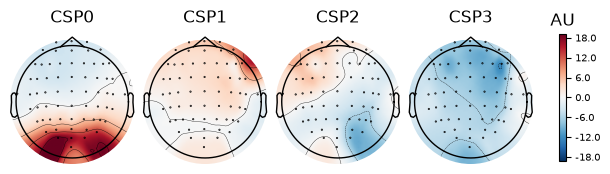

In [46]:
csp_model.plot_patterns(
    epochs_train_csp.info,
    components=[0, 1, 2, 3],
    ch_type="eeg"
)

## 9. Frequency-Specific CSP Analysis
CSP + LDA was evaluated separately in the mu (8–13 Hz) and beta (13–30 Hz) bands to determine whether one motor-related frequency band provided stronger discriminative information.

In [47]:
epochs_train_mu = epochs_train.copy().filter(
    l_freq=8,
    h_freq=13
)

epochs12_mu = epochs12.copy().filter(
    l_freq=8,
    h_freq=13
)

X_train_mu = epochs_train_mu.get_data()
y_train_mu = epochs_train_mu.events[:, -1]

X_test_mu = epochs12_mu.get_data()
y_test_mu = epochs12_mu.events[:, -1]

Setting up band-pass filter from 8 - 13 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 13.00 Hz
- Upper transition bandwidth: 3.25 Hz (-6 dB cutoff frequency: 14.62 Hz)
- Filter length: 265 samples (1.656 s)

Setting up band-pass filter from 8 - 13 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 13.00 Hz
- Upper transition bandwidth: 3.25 Hz (-6 dB cutoff frequency: 14.62 Hz)
- Filt

In [48]:
csp_mu = CSP(
    n_components=4,
    reg=None,
    log=True,
    norm_trace=False
)

lda_mu = LinearDiscriminantAnalysis()

model_mu = make_pipeline(
    csp_mu,
    lda_mu
)

model_mu.fit(X_train_mu, y_train_mu)

acc_mu = model_mu.score(
    X_test_mu,
    y_test_mu
)

print("Mu CSP + LDA Run 12 accuracy:", acc_mu)

Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Mu CSP + LDA Run 12 accuracy: 0.8


In [49]:
epochs_train_beta = epochs_train.copy().filter(
    l_freq=13,
    h_freq=30
)

epochs12_beta = epochs12.copy().filter(
    l_freq=13,
    h_freq=30
)

X_train_beta = epochs_train_beta.get_data()
y_train_beta = epochs_train_beta.events[:, -1]

X_test_beta = epochs12_beta.get_data()
y_test_beta = epochs12_beta.events[:, -1]

csp_beta = CSP(
    n_components=4,
    reg=None,
    log=True,
    norm_trace=False
)

lda_beta = LinearDiscriminantAnalysis()

model_beta = make_pipeline(
    csp_beta,
    lda_beta
)

model_beta.fit(X_train_beta, y_train_beta)

acc_beta = model_beta.score(
    X_test_beta,
    y_test_beta
)

print("Beta CSP + LDA Run 12 accuracy:", acc_beta)

Setting up band-pass filter from 13 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 13.00
- Lower transition bandwidth: 3.25 Hz (-6 dB cutoff frequency: 11.38 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 163 samples (1.019 s)

Setting up band-pass filter from 13 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 13.00
- Lower transition bandwidth: 3.25 Hz (-6 dB cutoff frequency: 11.38 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)


In [50]:
y_pred_mu = model_mu.predict(X_test_mu)

cm_mu = confusion_matrix(
    y_test_mu,
    y_pred_mu,
    labels=[2, 3]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mu,
    display_labels=["Left", "Right"]
)

disp.plot()
plt.title("Mu CSP + LDA Run 12 Confusion Matrix")
plt.show()

NOTE: plot_patterns() is a legacy function. New code should use get_spatial_filter_from_estimator(clf, info=info).plot_patterns().


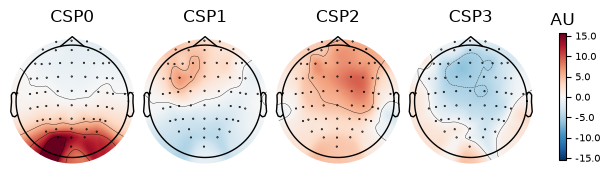

In [51]:
csp_mu_model = model_mu.named_steps["csp"]

csp_mu_model.plot_patterns(
    epochs_train_mu.info,
    components=[0, 1, 2, 3],
    ch_type="eeg"
)

## 10. Leave-One-Run-Out Evaluation

To assess cross-run robustness, each recording run was held out once for testing while the remaining two runs were used for training. The mu-band CSP + LDA model was evaluated using the same pipeline for all three splits.

In [52]:
runs_epochs = {
    "Run 4": epochs,
    "Run 8": epochs8,
    "Run 12": epochs12
}

loro_results = []

for test_run, test_epochs in runs_epochs.items():

    # Use the other two runs as training data
    train_epochs_list = [
        ep for run_name, ep in runs_epochs.items()
        if run_name != test_run
    ]

    train_epochs = mne.concatenate_epochs(train_epochs_list)

    # Mu-band filtering: 8–13 Hz
    train_mu = train_epochs.copy().filter(
        l_freq=8,
        h_freq=13,
        verbose=False
    )

    test_mu = test_epochs.copy().filter(
        l_freq=8,
        h_freq=13,
        verbose=False
    )

    # EEG data and labels
    X_train_loro = train_mu.get_data()
    y_train_loro = train_mu.events[:, -1]

    X_test_loro = test_mu.get_data()
    y_test_loro = test_mu.events[:, -1]

    # CSP + LDA model
    model_loro = make_pipeline(
        CSP(
            n_components=4,
            reg=None,
            log=True,
            norm_trace=False
        ),
        LinearDiscriminantAnalysis()
    )

    model_loro.fit(X_train_loro, y_train_loro)

    accuracy = model_loro.score(
        X_test_loro,
        y_test_loro
    )

    loro_results.append({
        "Held-out Run": test_run,
        "Accuracy": accuracy
    })

loro_results = pd.DataFrame(loro_results)

loro_results

C:\Users\13706\AppData\Local\Temp\ipykernel_7260\1078830197.py:17: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  train_epochs = mne.concatenate_epochs(train_epochs_list)


Not setting metadata
30 matching events found
No baseline correction applied
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Not setting metadata
30 matching events found
No baseline correction applied
Computing rank from data with rank=None


C:\Users\13706\AppData\Local\Temp\ipykernel_7260\1078830197.py:17: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  train_epochs = mne.concatenate_epochs(train_epochs_list)


    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.4e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Not setting metadata
30 matching events found
No baseline correction applied
Computing rank from data with rank=None


C:\Users\13706\AppData\Local\Temp\ipykernel_7260\1078830197.py:17: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  train_epochs = mne.concatenate_epochs(train_epochs_list)


    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.


,Held-out Run,Accuracy
0,Run 4,0.733333
1,Run 8,0.666667
2,Run 12,0.800000


In [53]:
mean_loro_accuracy = loro_results["Accuracy"].mean()

print(
    "Mean leave-one-run-out accuracy:",
    mean_loro_accuracy
)

Mean leave-one-run-out accuracy: 0.7333333333333334


The mu-band CSP + LDA model showed relatively consistent cross-run performance. 
Leave-one-run-out accuracies were 73.3%, 66.7%, and 80.0% for Runs 4, 8, and 12, respectively, with a mean accuracy of 73.3%. 
This suggests that the model captured some reproducible motor-imagery-related structure across recording runs, although the small sample size limits the precision of the performance estimate.

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
bars = plt.bar(
    loro_results["Held-out Run"],
    loro_results["Accuracy"]
)

plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Mu-band CSP + LDA Leave-One-Run-Out Evaluation")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 11. Results Summary
This section summarizes the exploratory model comparison on Run 12 and the leave-one-run-out evaluation of mu-band CSP + LDA across three recording runs.

In [55]:
results_summary = pd.DataFrame({
    "Model": [
        "Logistic (4 band-power features)",
        "CSP + LDA (8-30 Hz)",
        "CSP + LDA (beta 13-30 Hz)",
        "CSP + LDA (mu 8-13 Hz)"
    ],
    "Run12_accuracy": [
        0.60,
        0.6667,
        0.7333,
        0.80
    ]
})

results_summary

,Model,Run12_accuracy
0,Logistic (4 band-power features),0.6000
1,CSP + LDA (8-30 Hz),0.6667
2,CSP + LDA (beta 13-30 Hz),0.7333
3,CSP + LDA (mu 8-13 Hz),0.8000


In [56]:
plt.figure(figsize=(9, 5))
plt.bar(
    results_summary["Model"],
    results_summary["Run12_accuracy"]
)

plt.ylabel("Run 12 Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.title("Comparison of BCI Decoding Models")
plt.tight_layout()
plt.show()

**Cross-Run Robustness Evaluation**

The mu-band CSP + LDA model achieved leave-one-run-out accuracies of 73.3%, 66.7%, and 80.0% for Runs 4, 8, and 12, respectively, with a mean accuracy of 73.3%.

These exploratory results suggest that the model can extract discriminative EEG features across different recording runs. However, the small sample size and exploratory model selection limit the reliability of the estimated generalization performance.

## 12. Limitations and Future Work

### Limitations

**1. Small sample size**

The analysis included only 30 training trials and 15 held-out trials in each evaluation split. Such a small sample size leads to substantial uncertainty in classification accuracy and increases the risk of overfitting.

**2. Single-subject analysis**

Only Subject 1 from the PhysioNet EEG Motor Movement/Imagery Dataset was analyzed. Therefore, the results cannot establish whether the trained models would generalize to other individuals.

**3. Exploratory model selection**

Multiple classification approaches and frequency bands were compared using Run 12. Consequently, Run 12 was not maintained as a completely untouched final test set, and the observed accuracy may be optimistic. The subsequent leave-one-run-out analysis provides additional evidence of cross-run performance but does not eliminate this model-selection limitation.

**4. Limited physiological interpretability**

The CSP spatial patterns did not consistently show clear localization around the expected sensorimotor regions. Therefore, classification performance alone is insufficient to conclude that the models learned physiologically meaningful motor-imagery activity.

### Future Work

Future improvements could include evaluating additional subjects, using more recording runs, and applying filter-bank CSP to capture information across multiple frequency bands. More rigorous model selection using training-only cross-validation or nested cross-validation would also help provide less biased estimates of generalization performance.

In the longer term, transfer learning and domain adaptation techniques could be explored to improve robustness to variability across recording runs, sessions, and participants.